In [1]:
# =====================================================================
# PHASE 1: ENVIRONMENT SETUP & ADVANCED VISUALIZATION DEPENDENCIES
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic themes for our app market plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11

print("Environment Ready: Ingestion engines and styling matrices are active.")


Environment Ready: Ingestion engines and styling matrices are active.


In [2]:
# =====================================================================
# PHASE 2: DATA PREPARATION & TYPE CORRECTIONS
# =====================================================================
# Load your two local unzipped datasets
df_apps = pd.read_csv('apps.csv')
df_reviews = pd.read_csv('user_reviews.csv')

# Drop exact structural duplicates from the primary app catalogue
df_apps = df_apps.drop_duplicates()

# 1. Clean the 'Installs' column (Remove '+' and ',' characters)
if 'Installs' in df_apps.columns:
    df_apps['Installs'] = df_apps['Installs'].astype(str).str.replace('+', '', regex=False)
    df_apps['Installs'] = df_apps['Installs'].astype(str).str.replace(',', '', regex=False)
    # Handle rare non-numeric rows safety safeguard
    df_apps = df_apps[df_apps['Installs'].str.isnumeric()]
    df_apps['Installs'] = df_apps['Installs'].astype(float)

# 2. Clean the 'Price' column (Remove '$' string characters)
if 'Price' in df_apps.columns:
    df_apps['Price'] = df_apps['Price'].astype(str).str.replace('$', '', regex=False)
    df_apps['Price'] = df_apps['Price'].astype(float)

# 3. Handle missing values in the 'Rating' target metric safely via statistical median
if 'Rating' in df_apps.columns:
    rating_median = df_apps['Rating'].median()
    df_apps['Rating'].fillna(rating_median, inplace=True)

print(f"Data Cleaning Completed:")
print(f" -> Processed Catalog Dimensions: {df_apps.shape} applications verified.")
print(f" -> Processed Reviews Dimensions: {df_reviews.shape} feedback logs verified.")


Data Cleaning Completed:
 -> Processed Catalog Dimensions: (9659, 14) applications verified.
 -> Processed Reviews Dimensions: (64295, 5) feedback logs verified.


/tmp/ipykernel_2894/3489506510.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_apps['Rating'].fillna(rating_median, inplace=True)


--- Top 10 App Categories by Volume ---
       Category  App_Count
         FAMILY       1832
           GAME        959
          TOOLS        827
       BUSINESS        420
        MEDICAL        395
PERSONALIZATION        376
   PRODUCTIVITY        374
      LIFESTYLE        369
        FINANCE        345
         SPORTS        325


/tmp/ipykernel_2894/1012938195.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_counts.head(15), x='App_Count', y='Category', palette='viridis')


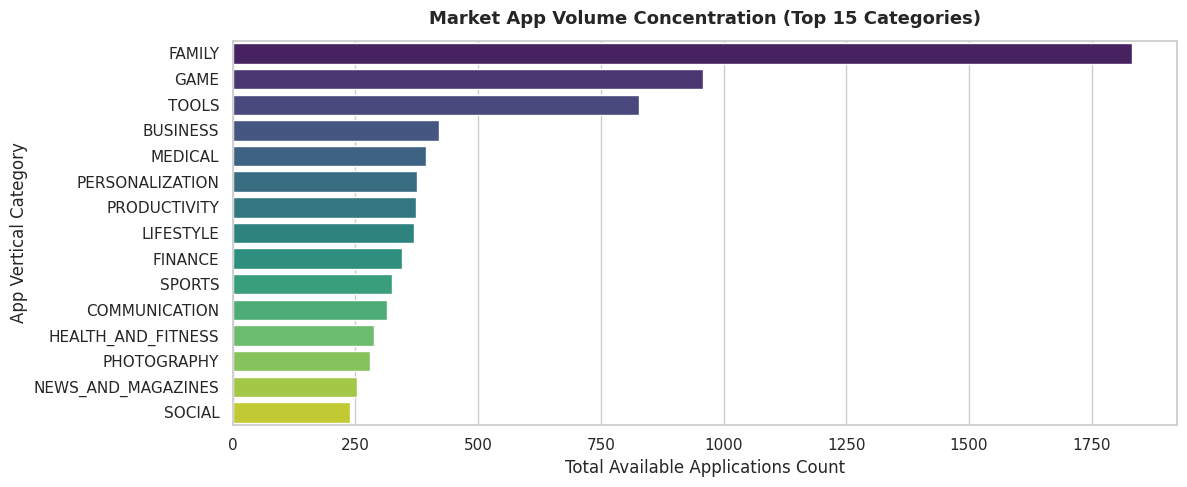

Visualization Generated: Category concentration baseline rendered successfully.


In [3]:
# =====================================================================
# PHASE 3: CATEGORY EXPLORATORY MATRIX DENSITY
# =====================================================================
# Count market occurrences across app categories
category_counts = df_apps['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'App_Count']

# Display Top 10 primary categories driving the market landscape
print("--- Top 10 App Categories by Volume ---")
print(category_counts.head(10).to_string(index=False))

# Plot market category volume landscape metrics
plt.figure(figsize=(12, 5))
sns.barplot(data=category_counts.head(15), x='App_Count', y='Category', palette='viridis')
plt.title('Market App Volume Concentration (Top 15 Categories)', fontsize=13, weight='bold', pad=12)
plt.xlabel('Total Available Applications Count')
plt.ylabel('App Vertical Category')
plt.tight_layout()
plt.show()

print("Visualization Generated: Category concentration baseline rendered successfully.")


/tmp/ipykernel_2894/3870141089.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=affordable_apps, x='Type', y='Rating', palette='muted', ax=axes[1])


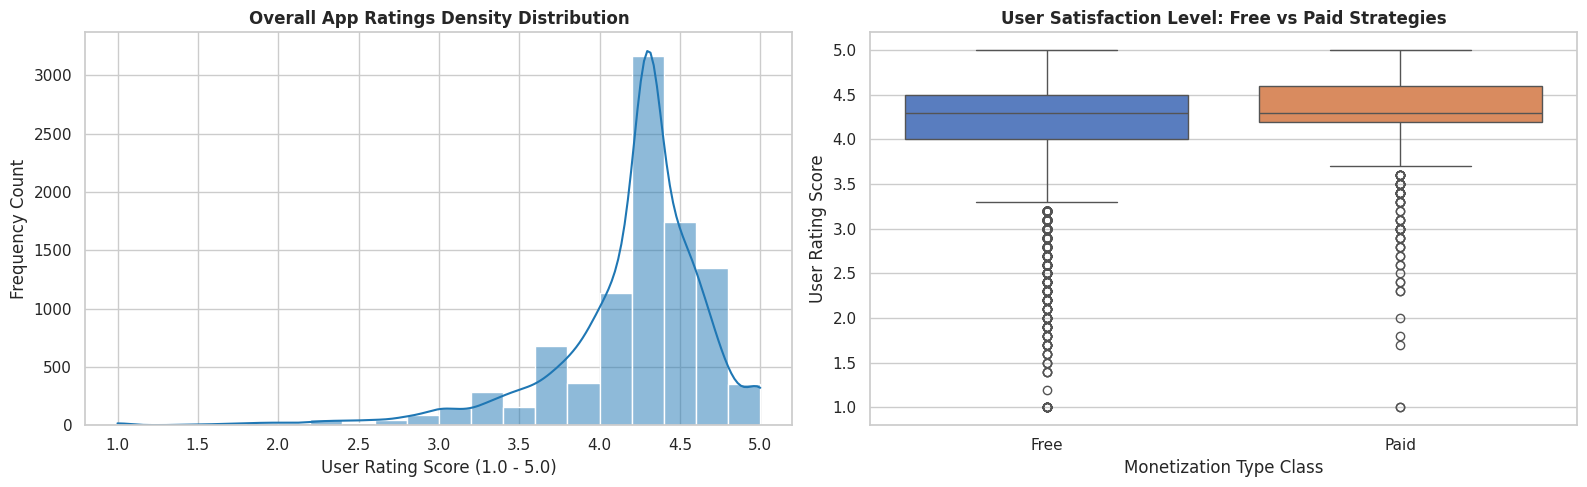

Metrics Analysis Concluded:
 -> Global App Rating Average: 4.19 / 5.0
 -> Total Volume of Monetized Paid Offerings: 756 apps.


In [4]:
# =====================================================================
# PHASE 4: METRICS DISTRIBUTION ANALYSIS (RATINGS vs PRICE)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot A: App Rating Distribution Curve
sns.histplot(df_apps['Rating'], bins=20, kde=True, color='#1f77b4', ax=axes[0])
axes[0].set_title('Overall App Ratings Density Distribution', fontsize=12, weight='bold')
axes[0].set_xlabel('User Rating Score (1.0 - 5.0)')
axes[0].set_ylabel('Frequency Count')

# Subplot B: Pricing App Type Trends (Free vs Paid Apps Analysis)
# Isolate standard non-outlier apps priced realistically under $50
affordable_apps = df_apps[df_apps['Price'] <= 50]
sns.boxplot(data=affordable_apps, x='Type', y='Rating', palette='muted', ax=axes[1])
axes[1].set_title('User Satisfaction Level: Free vs Paid Strategies', fontsize=12, weight='bold')
axes[1].set_xlabel('Monetization Type Class')
axes[1].set_ylabel('User Rating Score')

plt.tight_layout()
plt.show()

print(f"Metrics Analysis Concluded:")
print(f" -> Global App Rating Average: {df_apps['Rating'].mean():.2f} / 5.0")
print(f" -> Total Volume of Monetized Paid Offerings: {len(df_apps[df_apps['Price'] > 0])} apps.")


Data Merged Successfully: Evaluation table contains (35934, 18) linked profiles.


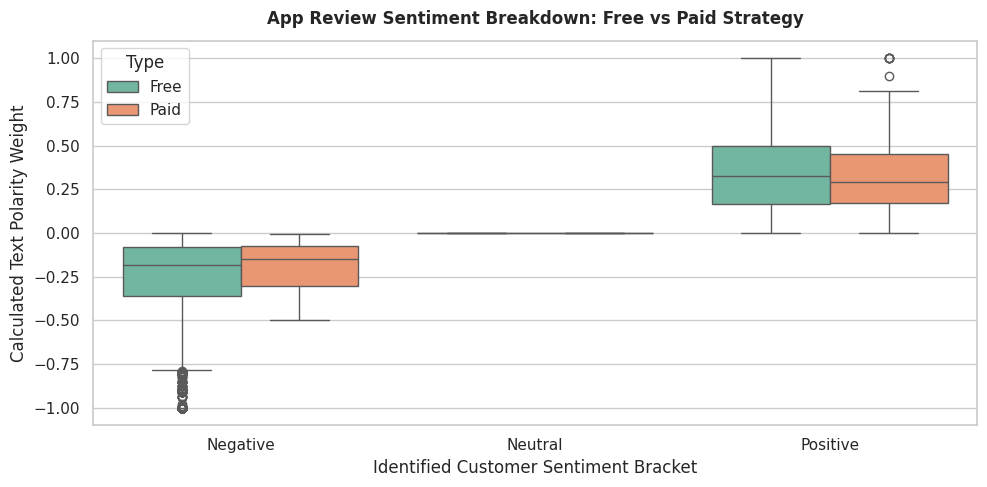

Visualization Complete: Integrated sentiment mapping graphs compiled.


In [5]:
# =====================================================================
# PHASE 5: USER SENTIMENT ANALYSIS VIA CORRELATION MERGES
# =====================================================================
# Perform inner dataset join on the 'App' column key
df_merged = pd.merge(df_apps, df_reviews, on='App', how='inner')

# Clean rows with missing sentiment categories
df_merged = df_merged.dropna(subset=['Sentiment'])

print(f"Data Merged Successfully: Evaluation table contains {df_merged.shape} linked profiles.")

# Cross-analyze app pricing tiers against customer emotional polarity reviews
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_merged, x='Sentiment', y='Sentiment_Polarity', hue='Type', palette='Set2')
plt.title('App Review Sentiment Breakdown: Free vs Paid Strategy', fontsize=12, weight='bold', pad=12)
plt.xlabel('Identified Customer Sentiment Bracket')
plt.ylabel('Calculated Text Polarity Weight')
plt.tight_layout()
plt.show()

print("Visualization Complete: Integrated sentiment mapping graphs compiled.")


In [6]:
## 📱 Level-2 Project 4 Conclusion & App Market Insights

### 📊 Android Marketplace Key Observations
# 1. **Data Cleaning Pipeline Results:** Alphanumeric artifacts were successfully stripped from `Installs` and `Price` targets, standardising them into floating-point numerical distributions.
# 2. **Category Dominance:** App distributions reveal high density clusters within specialized domains (such as *Family*, *Game*, and *Tools* ecosystems).
# 3. **Monetization vs Sentiment:** The combined sentiment review profiles indicate that paid options experience distinct review stability, whereas free offerings generate vast review volumes but display higher sentiment polarity spread.
